In [17]:
# correlation between interest rates and the housing market
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred

# Get the current price of all S&P 500 stocks
import yfinance as yf

yf.pdr_override()

plt.ion()

FRED_API_KEY = "612c90fb30af12767bbcaf9513bac5ed"
fred = Fred(api_key=FRED_API_KEY)


In [18]:
def plot_it(data: pd.Series, title: str, figsize: tuple[int, int] = (15, 5)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(data)
    ax.grid(True, which="both")
    plt.title(title)


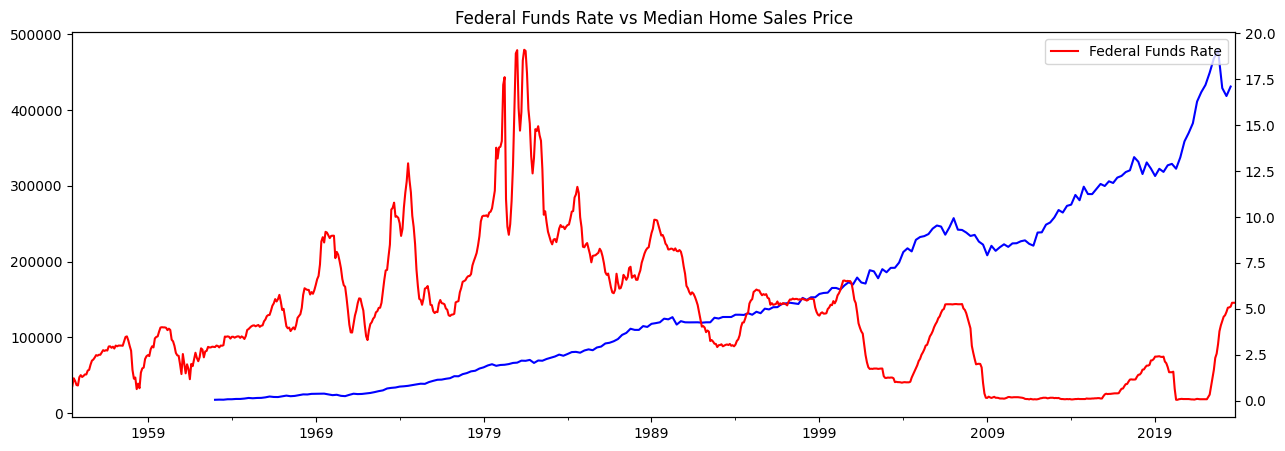

In [19]:
irate = fred.get_series("FEDFUNDS").dropna()
df_home_prices = fred.get_series("MSPUS").dropna()

fig, ax = plt.subplots(figsize=(15, 5))
irate.plot(
    ax=ax,
    secondary_y=True,
    color="red",
    label="Federal Funds Rate",
)
df_home_prices.plot(ax=ax, color="blue", label="Median Home Sales Price")

plt.title("Federal Funds Rate vs Median Home Sales Price")
plt.legend(["Federal Funds Rate", "Median Home Sales Price"])
plt.show()


In [20]:
# Correlation Coefficient = 0.6: A moderate positive relationship.
print(
    f"Federal Funds Rate correlation with Median Home Sales Price: {irate.corr(df_home_prices, method='pearson')}"
)


Federal Funds Rate correlation with Median Home Sales Price: -0.6048362697906242


In [21]:
# Get the data for the S&P 500 from Yahoo Finance
sp5 = yf.Ticker("^GSPC").history(start="1980-01-01", interval="1mo")
sp5.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1985-01-01 00:00:00-05:00,167.199997,180.270004,163.360001,179.630005,2673710000,0.0,0.0
1985-02-01 00:00:00-05:00,179.630005,183.949997,177.750000,181.179993,2194620000,0.0,0.0
1985-03-01 00:00:00-05:00,181.179993,183.889999,176.529999,180.660004,2153090000,0.0,0.0
1985-04-01 00:00:00-05:00,180.660004,183.610001,177.860001,179.830002,1981880000,0.0,0.0
1985-05-01 00:00:00-04:00,179.830002,189.979996,178.350006,189.550003,2350340000,0.0,0.0


In [22]:
# Change the date format to YYYY-MM-DD
sp5.index = sp5.index.to_series().apply(
    lambda x: pd.Timestamp(pd.Timestamp(x).strftime("%Y-%m-%d"))
)
sp5


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1985-01-01,167.199997,180.270004,163.360001,179.630005,2673710000,0.0,0.0
1985-02-01,179.630005,183.949997,177.750000,181.179993,2194620000,0.0,0.0
1985-03-01,181.179993,183.889999,176.529999,180.660004,2153090000,0.0,0.0
1985-04-01,180.660004,183.610001,177.860001,179.830002,1981880000,0.0,0.0
1985-05-01,179.830002,189.979996,178.350006,189.550003,2350340000,0.0,0.0
...,...,...,...,...,...,...,...
2023-07-01,4450.479980,4607.069824,4385.049805,4588.959961,75063200000,0.0,0.0
2023-08-01,4578.830078,4584.620117,4335.310059,4507.660156,86840820000,0.0,0.0
2023-09-01,4530.600098,4541.250000,4238.629883,4288.049805,73482980000,0.0,0.0


In [23]:
# Make sure that both dataframes start and end at the same index
start_date = max(sp5.index.min(), irate.index.min())
end_date = min(sp5.index.max(), irate.index.max())

print(f"Start Date: {start_date}, End Date: {end_date}")

sp5 = sp5.loc[start_date:end_date]
irate = irate.loc[start_date:end_date]


Start Date: 1985-01-01 00:00:00, End Date: 2023-10-01 00:00:00


In [24]:
sp5


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1985-01-01,167.199997,180.270004,163.360001,179.630005,2673710000,0.0,0.0
1985-02-01,179.630005,183.949997,177.750000,181.179993,2194620000,0.0,0.0
1985-03-01,181.179993,183.889999,176.529999,180.660004,2153090000,0.0,0.0
1985-04-01,180.660004,183.610001,177.860001,179.830002,1981880000,0.0,0.0
1985-05-01,179.830002,189.979996,178.350006,189.550003,2350340000,0.0,0.0
...,...,...,...,...,...,...,...
2023-06-01,4183.029785,4458.479980,4171.640137,4450.379883,87983140000,0.0,0.0
2023-07-01,4450.479980,4607.069824,4385.049805,4588.959961,75063200000,0.0,0.0
2023-08-01,4578.830078,4584.620117,4335.310059,4507.660156,86840820000,0.0,0.0


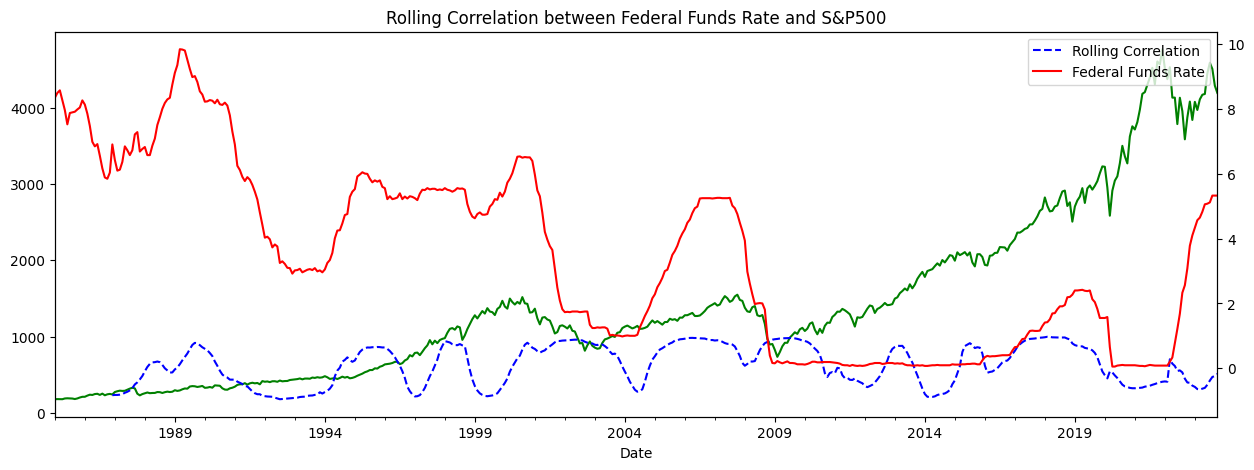

In [25]:
sp5 = sp5["Close"]
roll_corr = sp5.rolling(24).corr(irate)


fig, ax = plt.subplots(figsize=(15, 5))

roll_corr.plot(
    ax=ax,
    color="blue",
    label="Rolling Correlation",
    secondary_y=True,
    linestyle="--",
)
irate.plot(
    ax=ax,
    color="red",
    label="Federal Funds Rate",
    secondary_y=True,
)
sp5.plot(ax=ax, color="green", label="S&P500", secondary_y=False)


plt.legend(["Rolling Correlation", "Federal Funds Rate", "S&P500"])
plt.title("Rolling Correlation between Federal Funds Rate and S&P500")
plt.show()


In [26]:
# Spikes in the cost of borrowing, and in energy prices, have been forerunners of recession in the past

# Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis (DGS10)
df_treasury = fred.get_series("DGS10").dropna()

# Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
df_oil = fred.get_series("DCOILWTICO").dropna()
print(
    f"Correlation between treasury yields and crude oil prices: {df_treasury.corr(df_oil, method='pearson')}"
)


Correlation between treasury yields and crude oil prices: -0.6684342051585916


In [27]:
print(f"Correlation of S&P500 and Federal Interest Rates: {sp5.corr(irate)}")


Correlation of S&P500 and Federal Interest Rates: -0.5214847832927891


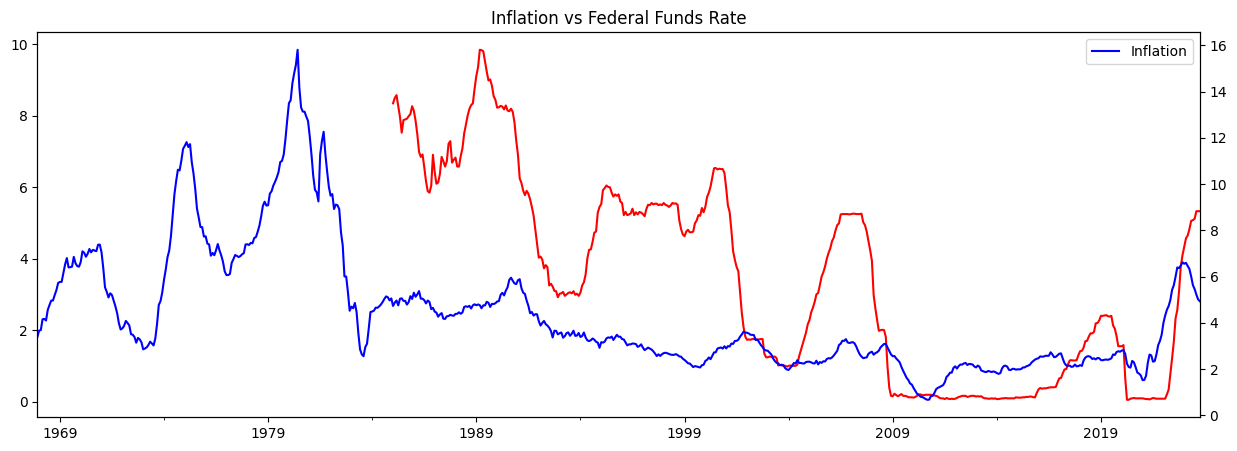

In [28]:
# RELATIONSHIP BETWEEN INTEREST RATES AND INFLATION
# Sticky Price Consumer Price Index less Food and Energy (CORESTICKM159SFRBATL)
data = fred.get_series("CORESTICKM159SFRBATL")
inflation = data.dropna()

fig, ax = plt.subplots(figsize=(15, 5))
inflation.plot(ax=ax, color="blue", label="Inflation", secondary_y=True)
irate.plot(ax=ax, color="red", label="Federal Funds Rate")
plt.title("Inflation vs Federal Funds Rate")
plt.legend(["Inflation", "Federal Funds Rate"])
plt.show()


In [29]:
# NOTE: .corr() sanity check
def gdp_rate_of_change():
    gdp = fred.get_series("GDP")
    rolling_avg = gdp.rolling(window=5).mean()
    rate_of_change = rolling_avg.pct_change()
    return gdp.dropna(), rate_of_change.dropna()


ONE_YEAR = -5
gdp, gdp_roc = gdp_rate_of_change()
gdp, gdp_roc = gdp[ONE_YEAR:], gdp_roc[ONE_YEAR:]

gdp.corr(gdp_roc)


-0.9194599487687883